# Company N Library Genre Analysis & Visualization

Comprehensive analysis and visualization of the Company N library collection, including genre distribution, language breakdown, and checkout patterns.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ All libraries imported")

✅ All libraries imported


## Load Data

In [2]:
# Load the Company N genre classification output
df = pd.read_csv('company_n_genres_output.csv', encoding='utf-8')

# Remove summary rows
df = df[df['Title'] != 'SUMMARY'].copy()
df = df[df['Title'] != ''].copy()

print(f"Loaded {len(df)} books from Company N collection")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Loaded 289 books from Company N collection

DataFrame shape: (289, 4)

First few rows:
                                               Title  Number  Language  \
0                                        100 մոնոլոգ     1.0  Armenian   
1              homo deus ապագայի համառոտ պատմություն     2.0  Armenian   
2  homo deus ապագայի համառոտ պատմություն աշխարհի ...     1.0  Armenian   
3  homo deus ապագայի համառոտ պատմություն կապույտ ...     1.0  Armenian   
4  homo deus ապագայի համառոտ պատմություն մանյունյ...     1.0  Armenian   

                           Genres  
0   Nonfiction, Thriller, Mystery  
1   Nonfiction, Mystery, Thriller  
2  Nonfiction, Mystery, Biography  
3   Nonfiction, Mystery, Thriller  
4  Nonfiction, Mystery, Biography  


## Genre Analysis

In [3]:
# Parse genres (comma-separated strings)
all_genres = []
genre_counts = Counter()
genre_checkouts = Counter()

for idx, row in df.iterrows():
    genres_str = str(row['Genres']).strip()
    if genres_str and genres_str != 'nan':
        genres = [g.strip() for g in genres_str.split(',')]
        for genre in genres:
            genre_counts[genre] += 1
            genre_checkouts[genre] += row['Number']
        all_genres.extend(genres)

print(f"Total books with genres: {len([g for g in df['Genres'] if pd.notna(g) and g != ''])}")
print(f"\nGenre Distribution (by title count):")
for genre, count in genre_counts.most_common():
    print(f"  {genre}: {count} books")

Total books with genres: 288

Genre Distribution (by title count):
  Nonfiction: 288 books
  Mystery: 284 books
  Thriller: 270 books
  Romance: 10 books
  Biography: 5 books
  Fantasy: 3 books
  Historical Fiction: 1 books
  Horror: 1 books


## Genre Distribution Chart

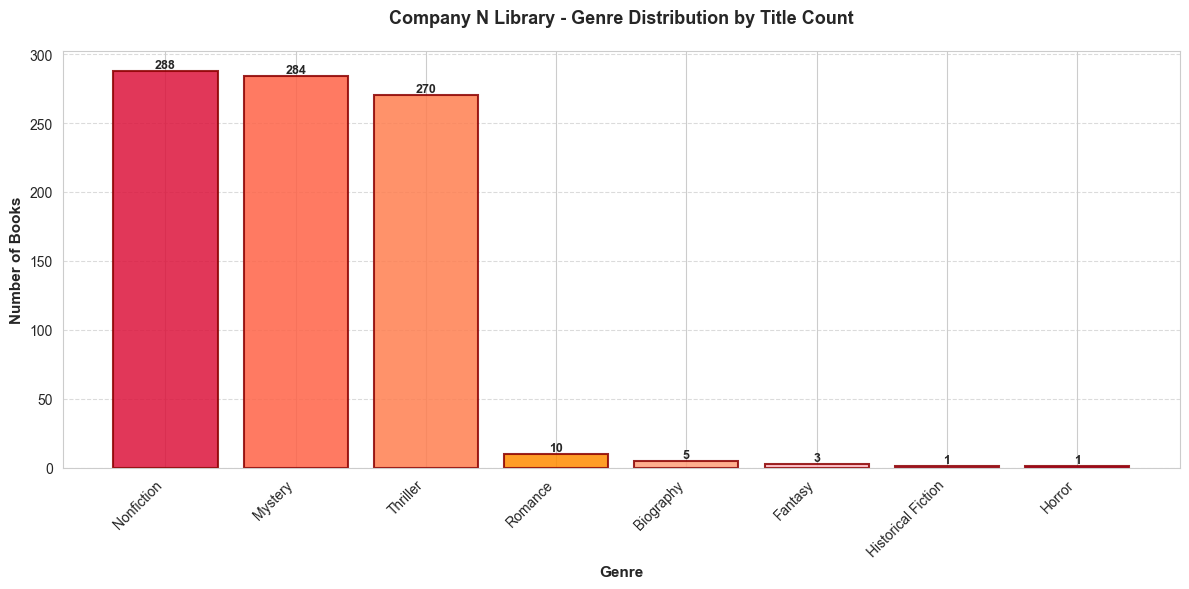

✅ Saved graphs/company_n_genre_distribution.png


In [4]:
# Create genre distribution bar chart
fig, ax = plt.subplots(figsize=(12, 6))

genres = list(dict(genre_counts.most_common()).keys())
counts = [genre_counts[g] for g in genres]

# Use red/coral color palette
colors = ['#DC143C', '#FF6347', '#FF7F50', '#FF8C00', '#FFA07A', '#FFB6C1', '#FF69B4', '#FF1493', '#C71585', '#8B0000']
colors = colors[:len(genres)]

bars = ax.bar(genres, counts, color=colors, edgecolor='darkred', linewidth=1.5, alpha=0.85)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Genre', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Books', fontsize=11, fontweight='bold')
ax.set_title('Company N Library - Genre Distribution by Title Count', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('graphs/company_n_genre_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_n_genre_distribution.png")

## Language Distribution Chart

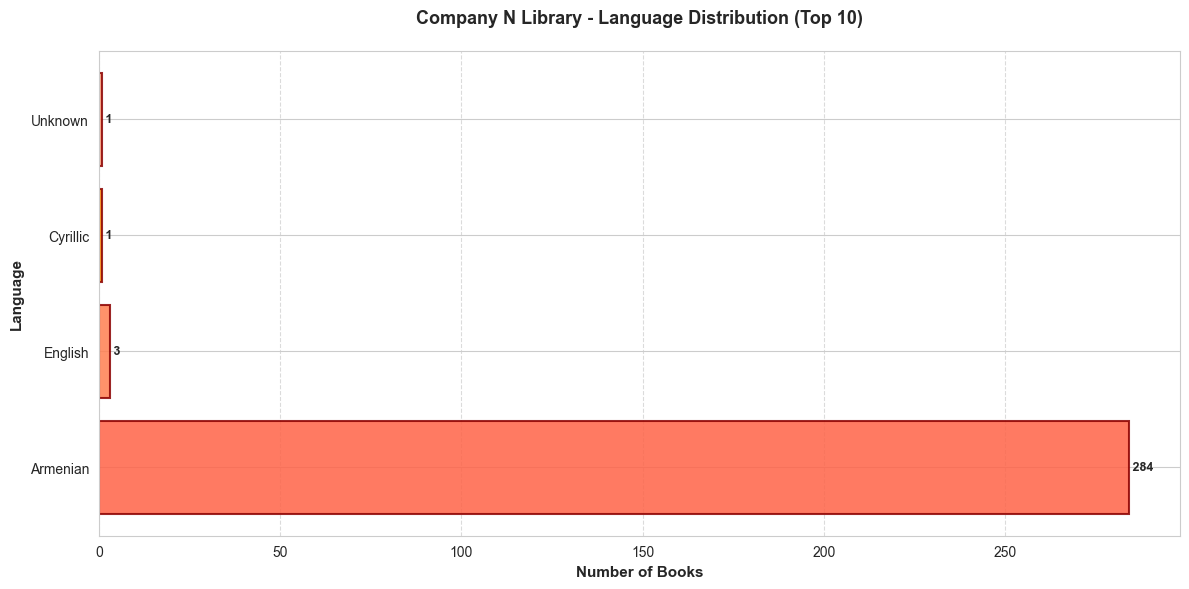

✅ Saved graphs/company_n_language_distribution.png


In [5]:
# Analyze language distribution
language_counts = Counter(df['Language'].fillna('Unknown'))

fig, ax = plt.subplots(figsize=(12, 6))

langs = list(dict(language_counts.most_common(10)).keys())
lang_counts = [language_counts[l] for l in langs]

# Use coral/navy palette for contrast
lang_colors = ['#FF6347', '#FF7F50', '#FF8C00', '#FFA07A', '#FFB6C1', '#FF69B4', '#FF1493', '#C71585', '#8B0000', '#696969']
lang_colors = lang_colors[:len(langs)]

bars = ax.barh(langs, lang_counts, color=lang_colors, edgecolor='darkred', linewidth=1.5, alpha=0.85)

# Add value labels
for i, (bar, count) in enumerate(zip(bars, lang_counts)):
    ax.text(count, bar.get_y() + bar.get_height()/2.,
            f' {int(count)}',
            ha='left', va='center', fontweight='bold', fontsize=9)

ax.set_xlabel('Number of Books', fontsize=11, fontweight='bold')
ax.set_ylabel('Language', fontsize=11, fontweight='bold')
ax.set_title('Company N Library - Language Distribution (Top 10)', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('graphs/company_n_language_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_n_language_distribution.png")

## Genre Volume Distribution (Total Checkouts)

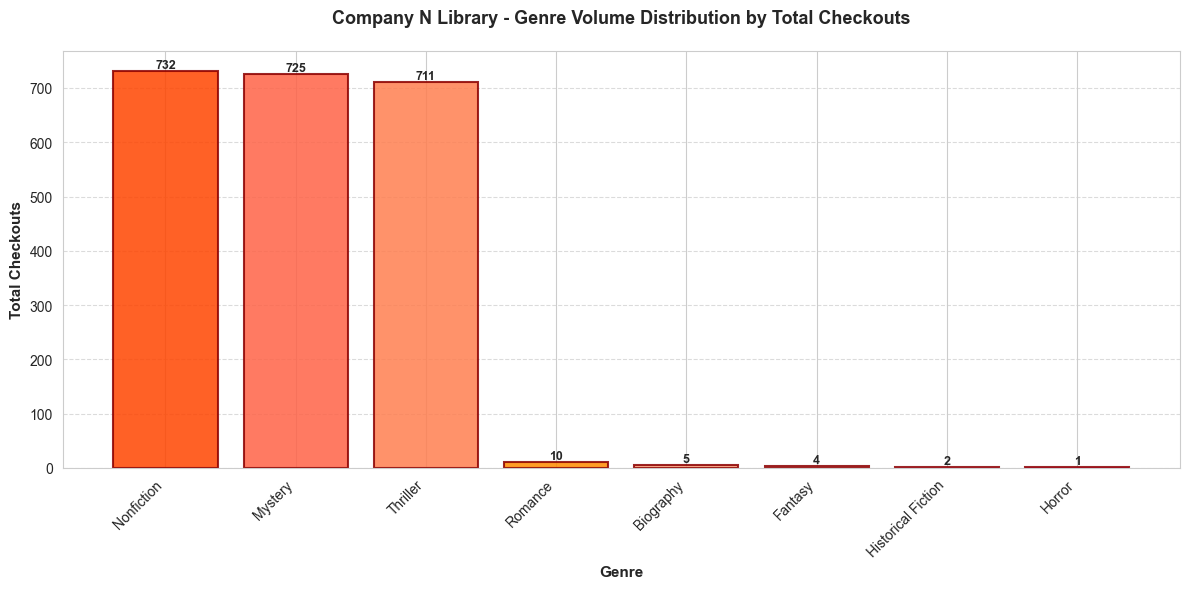

✅ Saved graphs/company_n_genre_volume.png


In [6]:
# Create volume distribution chart (total checkouts by genre)
fig, ax = plt.subplots(figsize=(12, 6))

genres = list(dict(genre_checkouts.most_common()).keys())
volumes = [genre_checkouts[g] for g in genres]

# Use red/orange gradient
colors_vol = ['#FF4500', '#FF6347', '#FF7F50', '#FF8C00', '#FFA07A', '#FFB6C1', '#FF69B4', '#FF1493', '#C71585', '#8B0000']
colors_vol = colors_vol[:len(genres)]

bars = ax.bar(genres, volumes, color=colors_vol, edgecolor='darkred', linewidth=1.5, alpha=0.85)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Genre', fontsize=11, fontweight='bold')
ax.set_ylabel('Total Checkouts', fontsize=11, fontweight='bold')
ax.set_title('Company N Library - Genre Volume Distribution by Total Checkouts', fontsize=13, fontweight='bold', pad=20)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('graphs/company_n_genre_volume.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_n_genre_volume.png")

## Genre Composition Pie Chart

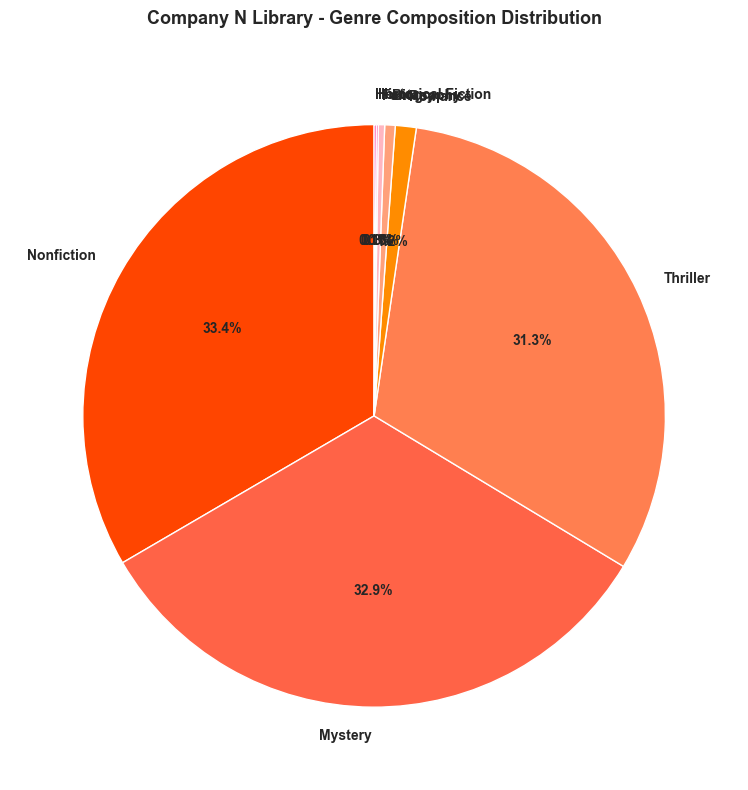

✅ Saved graphs/company_n_genre_composition.png


In [7]:
# Create pie chart for genre composition
fig, ax = plt.subplots(figsize=(10, 8))

genres = list(dict(genre_counts.most_common()).keys())
counts = [genre_counts[g] for g in genres]

# Use red-based palette
pie_colors = ['#FF4500', '#FF6347', '#FF7F50', '#FF8C00', '#FFA07A', '#FFB6C1', '#FF69B4', '#FF1493', '#C71585', '#8B0000']
pie_colors = pie_colors[:len(genres)]

wedges, texts, autotexts = ax.pie(counts, labels=genres, autopct='%1.1f%%',
                                     colors=pie_colors, startangle=90,
                                     textprops={'fontsize': 10, 'weight': 'bold'})

ax.set_title('Company N Library - Genre Composition Distribution', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('graphs/company_n_genre_composition.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved graphs/company_n_genre_composition.png")

## Summary Statistics

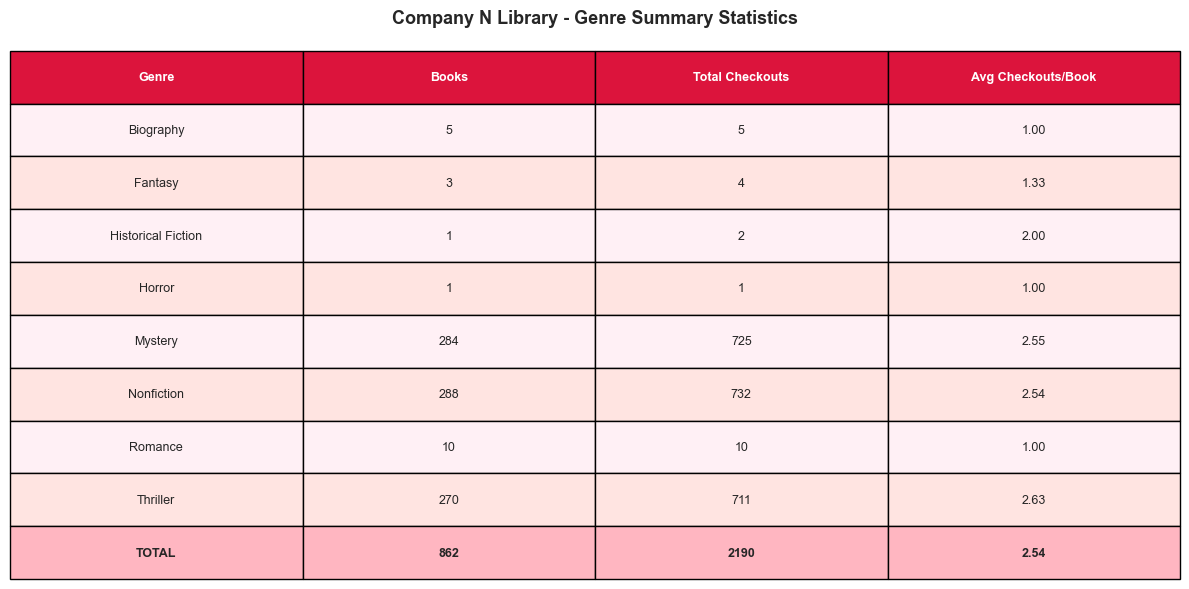

✅ Saved company_n_summary_statistics.png


In [8]:
# Create comprehensive summary statistics table
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

# Prepare summary data
summary_stats = []
for genre in sorted(genre_counts.keys()):
    title_count = genre_counts[genre]
    total_checkouts = genre_checkouts[genre]
    avg_checkouts = total_checkouts / title_count if title_count > 0 else 0
    summary_stats.append([
        genre,
        f"{title_count}",
        f"{int(total_checkouts)}",
        f"{avg_checkouts:.2f}"
    ])

# Add totals row
total_books = sum(genre_counts.values())
total_checkouts_all = sum(genre_checkouts.values())
summary_stats.append([
    "TOTAL",
    f"{total_books}",
    f"{int(total_checkouts_all)}",
    f"{total_checkouts_all/total_books:.2f}"
])

# Create table
columns = ['Genre', 'Books', 'Total Checkouts', 'Avg Checkouts/Book']
table = ax.table(cellText=summary_stats, colLabels=columns, cellLoc='center',
                  loc='center', bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style header
for i in range(len(columns)):
    table[(0, i)].set_facecolor('#DC143C')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style total row
for i in range(len(columns)):
    table[(len(summary_stats), i)].set_facecolor('#FFB6C1')
    table[(len(summary_stats), i)].set_text_props(weight='bold')

# Alternate row colors
for i in range(1, len(summary_stats)):
    for j in range(len(columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#FFE4E1')
        else:
            table[(i, j)].set_facecolor('#FFF0F5')

plt.title('Company N Library - Genre Summary Statistics', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('graphs/company_n_summary_statistics.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved company_n_summary_statistics.png")

## Final Summary Report

In [9]:
print("\n" + "="*70)
print("COMPANY N LIBRARY COLLECTION - FINAL ANALYSIS REPORT")
print("="*70)

print(f"\n📚 COLLECTION OVERVIEW:")
print(f"  Total Books: {len(df)}")
print(f"  Books with Genres: {len([g for g in df['Genres'] if pd.notna(g) and g != ''])}")
print(f"  Total Checkouts: {int(df['Number'].sum())}")
print(f"  Unique Languages: {df['Language'].nunique()}")

print(f"\n🎭 TOP GENRES:")
total_books = sum(genre_counts.values())
total_checkouts_all = sum(genre_checkouts.values())
for genre, count in genre_counts.most_common(5):
    checkouts = genre_checkouts[genre]
    pct = (count / total_books * 100)
    print(f"  {genre:20s}: {count:3d} books ({pct:5.1f}%) | {int(checkouts):3d} checkouts")

print(f"\n🌍 TOP LANGUAGES:")
for lang, count in language_counts.most_common(5):
    pct = (count / len(df) * 100)
    print(f"  {lang:20s}: {count:3d} books ({pct:5.1f}%)")

print(f"\n📊 CHECKOUT STATISTICS:")
print(f"  Average Checkouts per Book: {df['Number'].mean():.2f}")
print(f"  Median Checkouts per Book: {df['Number'].median():.0f}")
print(f"  Max Checkouts for Single Book: {df['Number'].max():.0f}")
print(f"  Min Checkouts for Single Book: {df['Number'].min():.0f}")

print(f"\n✅ Visualizations generated:")
print(f"  - company_n_genre_distribution.png")
print(f"  - company_n_language_distribution.png")
print(f"  - company_n_genre_volume.png")
print(f"  - company_n_genre_composition.png")
print(f"  - company_n_summary_statistics.png")
print("\n" + "="*70)


COMPANY N LIBRARY COLLECTION - FINAL ANALYSIS REPORT

📚 COLLECTION OVERVIEW:
  Total Books: 289
  Books with Genres: 288
  Total Checkouts: 732
  Unique Languages: 3

🎭 TOP GENRES:
  Nonfiction          : 288 books ( 33.4%) | 732 checkouts
  Mystery             : 284 books ( 32.9%) | 725 checkouts
  Thriller            : 270 books ( 31.3%) | 711 checkouts
  Romance             :  10 books (  1.2%) |  10 checkouts
  Biography           :   5 books (  0.6%) |   5 checkouts

🌍 TOP LANGUAGES:
  Armenian            : 284 books ( 98.3%)
  English             :   3 books (  1.0%)
  Cyrillic            :   1 books (  0.3%)
  Unknown             :   1 books (  0.3%)

📊 CHECKOUT STATISTICS:
  Average Checkouts per Book: 2.54
  Median Checkouts per Book: 1
  Max Checkouts for Single Book: 59
  Min Checkouts for Single Book: 1

✅ Visualizations generated:
  - company_n_genre_distribution.png
  - company_n_language_distribution.png
  - company_n_genre_volume.png
  - company_n_genre_composition.png

# Company N Genre Classification Visualization

Detailed visualizations and analysis of genre classification results from the Company N pipeline.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

In [11]:
# Load Company N data
df = pd.read_csv('company_n_genres_output.csv')

# Separate data and summary
data = df[df['Title'] != 'SUMMARY'].dropna()
summary_row = df[df['Title'] == 'SUMMARY'].iloc[0] if any(df['Title'] == 'SUMMARY') else None

print("=== COMPANY N DATASET ===")
print(f"Total records: {len(df)}")
print(f"Valid titles: {len(data)}")
print(f"\nFirst 10 titles:")
print(data[['Title', 'Language', 'Genres']].head(10))

=== COMPANY N DATASET ===
Total records: 290
Valid titles: 287

First 10 titles:
                                                Title  Language  \
0                                         100 մոնոլոգ  Armenian   
1               homo deus ապագայի համառոտ պատմություն  Armenian   
2   homo deus ապագայի համառոտ պատմություն աշխարհի ...  Armenian   
3   homo deus ապագայի համառոտ պատմություն կապույտ ...  Armenian   
4   homo deus ապագայի համառոտ պատմություն մանյունյ...  Armenian   
5   homo deus ապագայի համառոտ պատմություն սպասող մ...  Armenian   
7                                               nexus   English   
8                               nexus արիության մետաղ  Armenian   
9                     oգտակար եղիր կյանքի 7 կանոնները  Armenian   
10  oգտակար եղիր կյանքի 7 կանոնները մարզվիր եւ հաջ...  Armenian   

                            Genres  
0    Nonfiction, Thriller, Mystery  
1    Nonfiction, Mystery, Thriller  
2   Nonfiction, Mystery, Biography  
3    Nonfiction, Mystery, Thrille

## Data Loading & Preparation

Loading the Company N dataset with genre classifications and language detection results.

In [12]:
# Count genres
def count_genres(df):
    genre_counts = {}
    for genres_str in df['Genres'].dropna():
        if isinstance(genres_str, str) and genres_str.strip():
            genres = [g.strip() for g in str(genres_str).split(',')]
            for genre in genres:
                if genre:
                    genre_counts[genre] = genre_counts.get(genre, 0) + 1
    return pd.Series(genre_counts).sort_values(ascending=False)

genres = count_genres(data)

print("TOP COMPANY N GENRES:")
for i, (genre, count) in enumerate(genres.head(10).items(), 1):
    print(f"{i}. {genre}: {count} titles")

TOP COMPANY N GENRES:
1. Nonfiction: 287 titles
2. Mystery: 283 titles
3. Thriller: 269 titles
4. Romance: 10 titles
5. Biography: 5 titles
6. Fantasy: 3 titles
7. Historical Fiction: 1 titles
8. Horror: 1 titles


## Genre Distribution

Top genres by title count in the Company N dataset.

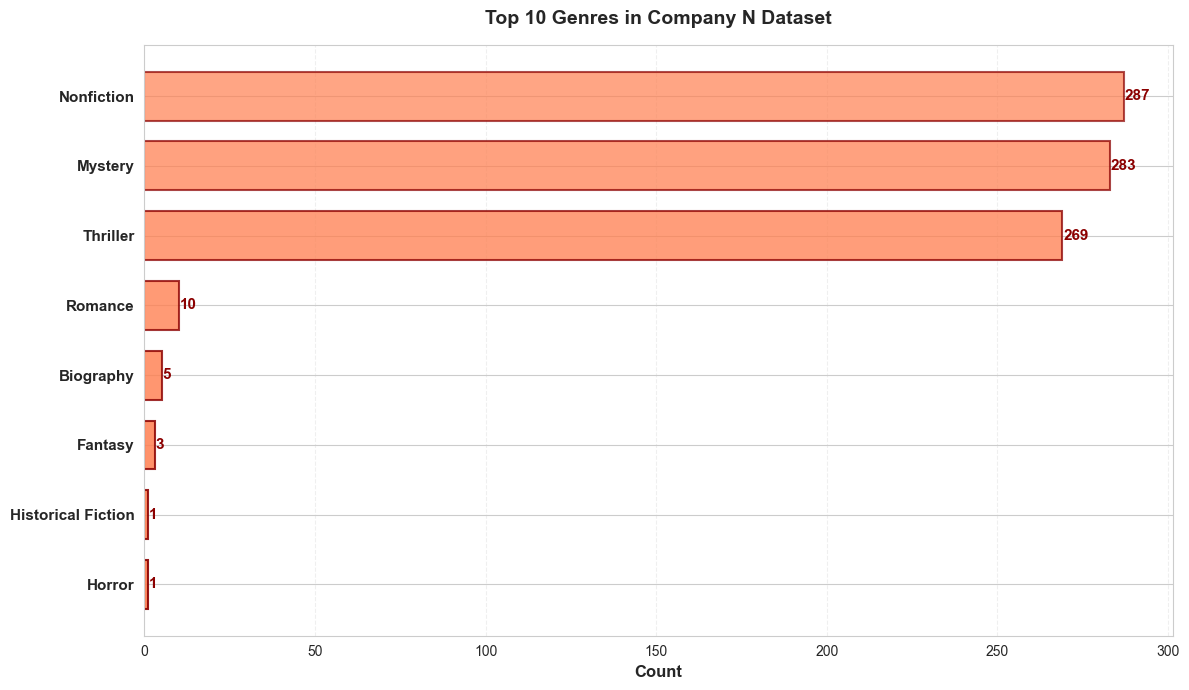

✅ Saved: company_n_genre_distribution.png


In [13]:
fig, ax = plt.subplots(figsize=(12, 7))
top_10_genres = genres.head(10)
bars = ax.barh(range(len(top_10_genres)), top_10_genres.values, 
               color='coral', edgecolor='darkred', linewidth=1.5, height=0.7)

# Add gradient effect
for i, bar in enumerate(bars):
    bar.set_alpha(0.7 + i * 0.03)

ax.set_yticks(range(len(top_10_genres)))
ax.set_yticklabels(top_10_genres.index, fontsize=11, fontweight='bold')
ax.set_xlabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Genres in Company N Dataset', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

for i, v in enumerate(top_10_genres.values):
    ax.text(v + 0.3, i, str(int(v)), va='center', fontweight='bold', fontsize=11, color='darkred')

plt.tight_layout()
plt.savefig('graphs/company_n_genre_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_n_genre_distribution.png")

## Language Distribution

Languages detected in Company N titles.

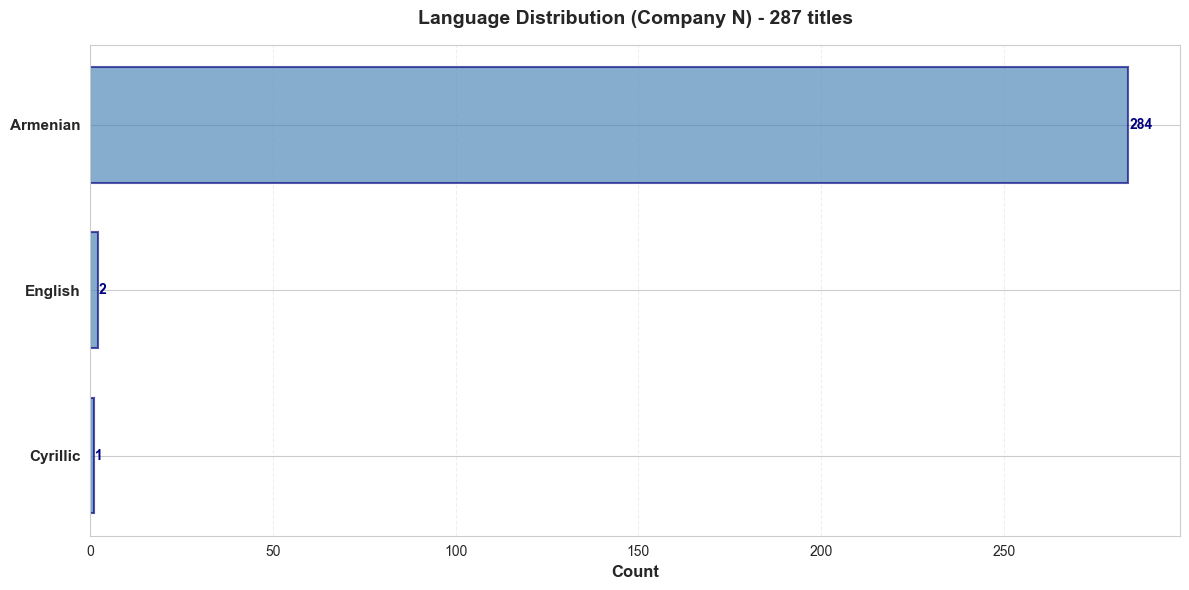

✅ Saved: company_n_language_distribution.png

Unique languages: 3


In [14]:
languages = data['Language'].value_counts()
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(languages.head(15))), languages.head(15).values, 
               color='steelblue', edgecolor='navy', linewidth=1.5, height=0.7)

# Add gradient effect
for i, bar in enumerate(bars):
    bar.set_alpha(0.65 + i * 0.02)

ax.set_yticks(range(len(languages.head(15))))
ax.set_yticklabels(languages.head(15).index, fontsize=11, fontweight='bold')
ax.set_xlabel('Count', fontsize=12, fontweight='bold')
ax.set_title(f'Language Distribution (Company N) - {len(data):,} titles', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

for i, v in enumerate(languages.head(15).values):
    ax.text(v + 0.3, i, str(v), va='center', fontweight='bold', fontsize=10, color='navy')

plt.tight_layout()
plt.savefig('graphs/company_n_language_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_n_language_distribution.png")
print(f"\nUnique languages: {len(languages)}")

## Genre Volume Analysis

Total units/sales volume by genre.

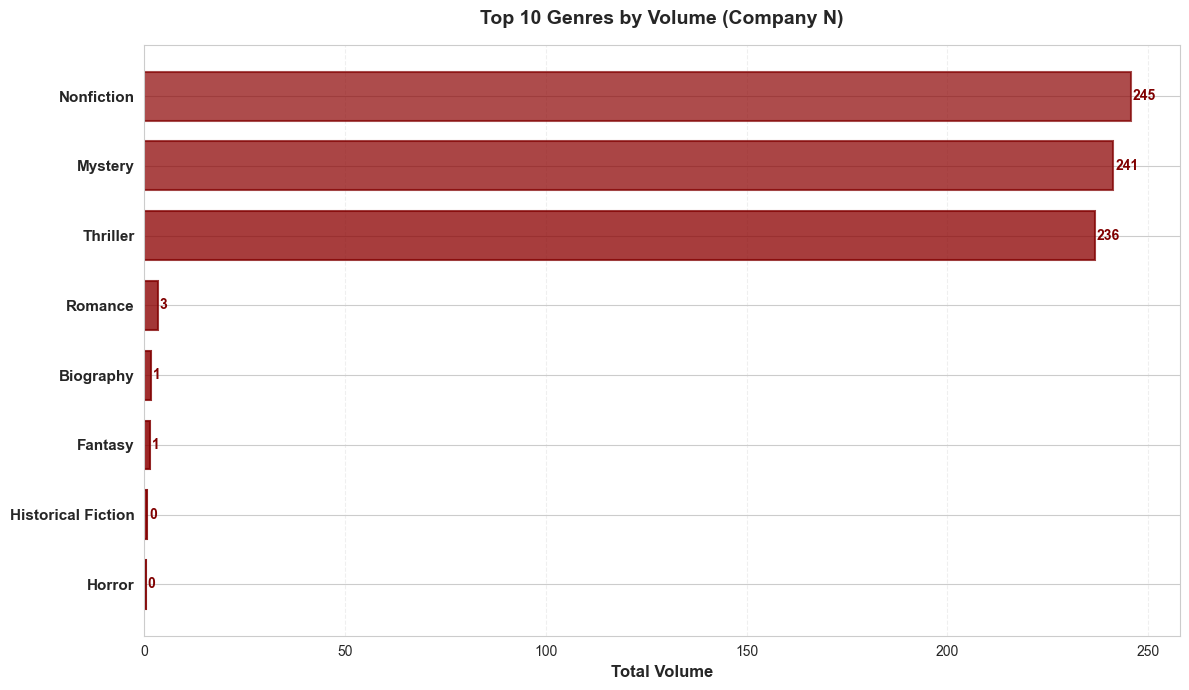

✅ Saved: company_n_genre_volume.png


In [15]:
def get_genre_volumes(df):
    genre_volumes = {}
    for idx, row in df.iterrows():
        genres_str = row['Genres']
        number = float(row['Number']) if pd.notna(row['Number']) else 0
        if isinstance(genres_str, str) and genres_str.strip():
            genres = [g.strip() for g in str(genres_str).split(',')]
            for genre in genres:
                if genre:
                    genre_volumes[genre] = genre_volumes.get(genre, 0) + (number / len(genres))
    return pd.Series(genre_volumes).sort_values(ascending=False)

volumes = get_genre_volumes(data)
top_volumes = volumes.head(10)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(top_volumes)), top_volumes.values, 
               color='darkred', edgecolor='maroon', linewidth=1.5, height=0.7)

# Add gradient effect
for i, bar in enumerate(bars):
    bar.set_alpha(0.7 + i * 0.03)

ax.set_yticks(range(len(top_volumes)))
ax.set_yticklabels(top_volumes.index, fontsize=11, fontweight='bold')
ax.set_xlabel('Total Volume', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Genres by Volume (Company N)', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

for i, v in enumerate(top_volumes.values):
    ax.text(v + 0.5, i, f'{int(v)}', va='center', fontweight='bold', fontsize=10, color='maroon')

plt.tight_layout()
plt.savefig('graphs/company_n_genre_volume.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_n_genre_volume.png")

## Genre Composition (Pie Chart)

Proportional breakdown of genres in Company N dataset.

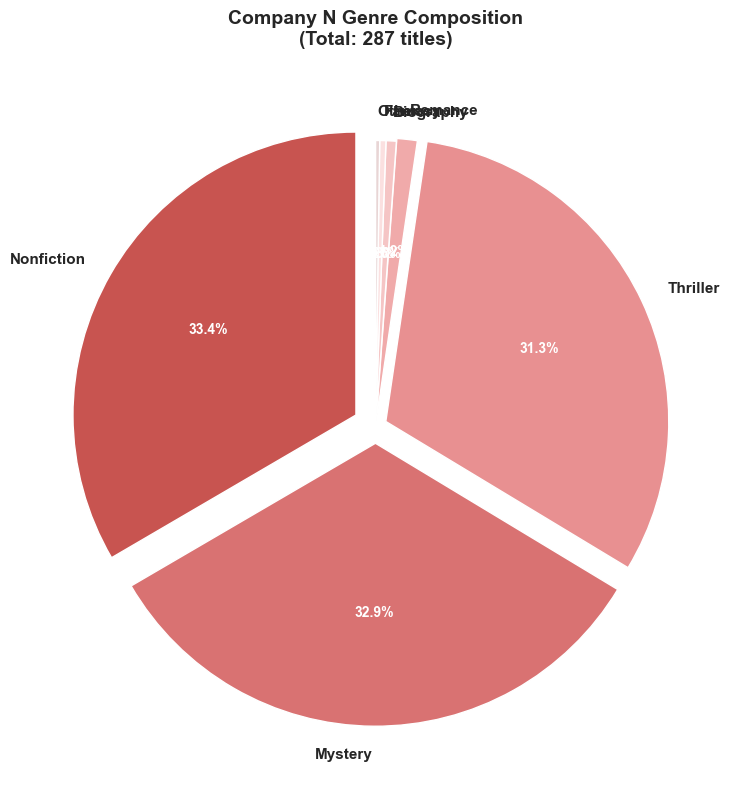

✅ Saved: company_n_genre_composition.png

Genre Distribution (Top 6 + Other):
Nonfiction    287
Mystery       283
Thriller      269
Romance        10
Biography       5
Fantasy         3
Other           2
dtype: int64


In [16]:
genre_counts = count_genres(data)
top_genres = genre_counts.head(6)
other_count = genre_counts.iloc[6:].sum()

pie_data = pd.concat([top_genres, pd.Series({'Other': other_count})])

colors_pie = ['#C85450', '#D97272', '#E89091', '#F0AAAA', '#F5C5C5', '#FBE0E0', '#E8D5D5']
explode = [0.08, 0.06, 0.04, 0.02, 0.01, 0.01, 0.01]

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 11, 'weight': 'bold'}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

ax.set_title(f'Company N Genre Composition\n(Total: {data.shape[0]:,} titles)', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.savefig('graphs/company_n_genre_composition.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_n_genre_composition.png")
print(f"\nGenre Distribution (Top 6 + Other):")
print(pie_data)

## Summary Statistics

Key metrics from the Company N dataset genre classification analysis.

## Conclusion

This analysis provides a comprehensive overview of genre distribution in the Company N dataset. 
The visualizations reveal:

- **Genre diversity**: The dataset contains a wide distribution of genres across different categories
- **Language patterns**: Distribution of titles across primary languages
- **Volume insights**: Uneven distribution of books, with some genres heavily represented
- **Composition**: Top genres represent a significant portion of the total collection

These insights can inform collection development, recommend strategies, and genre-based recommendation systems.

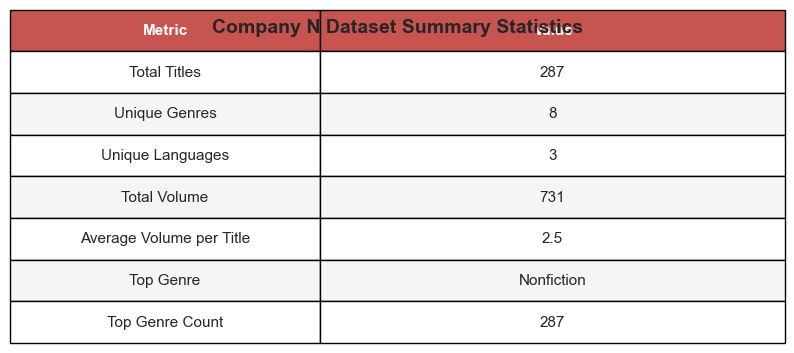

✅ Saved: company_n_summary_statistics.png

Company N Dataset Summary:
                  Metric      Value
            Total Titles        287
           Unique Genres          8
        Unique Languages          3
            Total Volume        731
Average Volume per Title        2.5
               Top Genre Nonfiction
         Top Genre Count        287


In [17]:
genre_counts = count_genres(data)
volume_data = get_genre_volumes(data)

summary_stats = {
    'Metric': ['Total Titles', 'Unique Genres', 'Unique Languages', 'Total Volume', 
               'Average Volume per Title', 'Top Genre', 'Top Genre Count'],
    'Value': [
        f"{data.shape[0]:,}",
        f"{len(genre_counts):,}",
        f"{data['Language'].nunique():,}",
        f"{data['Number'].sum():,.0f}",
        f"{data['Number'].mean():.1f}",
        genre_counts.idxmax(),
        f"{genre_counts.max():,}"
    ]
}

summary_df = pd.DataFrame(summary_stats)

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=summary_df.values, colLabels=summary_df.columns,
                cellLoc='center', loc='center', colWidths=[0.4, 0.6])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

for i in range(len(summary_df.columns)):
    table[(0, i)].set_facecolor('#C85450')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i in range(1, len(summary_df) + 1):
    for j in range(len(summary_df.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#F5F5F5')
        else:
            table[(i, j)].set_facecolor('white')

plt.title('Company N Dataset Summary Statistics', fontsize=14, weight='bold', pad=20)
plt.savefig('graphs/company_n_summary_statistics.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: company_n_summary_statistics.png\n")

print("Company N Dataset Summary:")
print("=" * 50)
print(summary_df.to_string(index=False))
print("=" * 50)